<a href="https://colab.research.google.com/github/tonycuenca99-hue/ARQUIVOS-IA/blob/main/APRENDIZADO_AULA_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [ ]:
#load the data
from google.colab import files
uploaded=files.upload()

Saving 01-04T184148_000_mode1.csv to 01-04T184148_000_mode1.csv


In [ ]:
# read csv file
filename= list(uploaded.keys())[0]
df=pd.read_csv(filename)


In [ ]:
df

,timestamp,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Actual_position,pSvolFilm::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Lag_error,pSpintor::VAX_speed
0,0.008000,0.199603,0.027420,628392628,-920.104980,5298555,2441.235352,0.899543,1379.999756
1,0.012000,0.281624,0.002502,628392625,-937.271118,5298565,2453.819092,0.874072,1379.999756
2,0.016000,0.349315,-0.018085,628392621,-951.004028,5298575,2476.469727,0.879806,1379.999756
3,0.020000,0.444450,-0.054680,628392617,-1019.668579,5298585,2501.637207,0.837500,1379.999756
4,0.024000,0.480923,-0.042770,628392613,-1023.101807,5298595,2519.254395,0.905347,1379.999756
...,...,...,...,...,...,...,...,...,...
2043,8.179999,0.371901,-0.012508,628403263,-1768.112183,5325580,2748.277588,1.031282,1199.999634
2044,8.183999,0.437352,-0.029764,628403256,-1802.444458,5325591,2763.377930,1.033880,1199.999634
2045,8.187999,0.474551,-0.020807,628403249,-1781.845093,5325602,2803.645752,0.962427,1199.999634
2046,8.191999,0.571133,-0.048983,628403242,-1860.809326,5325613,2823.779541,0.949072,1199.999634


In [ ]:
#ESTANDARIZAR OS DADOS
scaler=StandardScaler()
# Exclude the 'TIME' column before scaling
numerical_cols = df.select_dtypes(include=np.number).columns
df_scaled = scaler.fit_transform(df[numerical_cols])

In [ ]:
df_scaled

array([[-1.73120528,  0.61201456,  0.29525407, ..., -0.80598895,
         0.35116317,  0.5311377 ],
       [-1.72951383,  0.78069206,  0.02733617, ..., -0.79426446,
         0.11904376,  0.5311377 ],
       [-1.72782238,  0.91989868, -0.19402822, ..., -0.77316048,
         0.17130254,  0.5311377 ],
       ...,
       [ 1.72782237,  1.17744639, -0.22329333, ..., -0.46832497,
         0.92422688, -1.90425676],
       [ 1.72951383,  1.37606974, -0.52623916, ..., -0.44956597,
         0.8025227 , -1.90425676],
       [ 1.73120529,  1.28275958, -0.33982045, ..., -0.43784149,
         1.00388079, -1.90425676]])

In [ ]:
#aplicar metodo pca
pca=PCA()
X_pca=pca.fit_transform(df_scaled)

In [ ]:
pca.explained_variance_ratio_

array([4.54792681e-01, 2.13642057e-01, 1.39442464e-01, 9.67814056e-02,
       4.03857704e-02, 3.56825832e-02, 1.83419764e-02, 8.89162960e-04,
       4.19001883e-05])

In [ ]:
#criar dataframe dos resultados do PCA
df_pca=pd.DataFrame(X_pca, columns= [f"PC{i+1}" for i in range (X_pca.shape[1])])

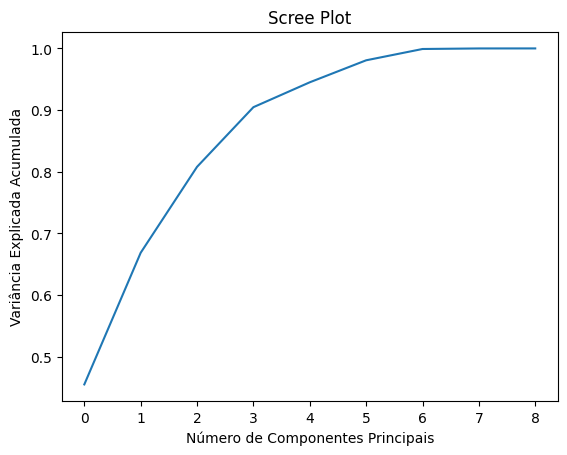

In [ ]:
#visualizar scree plot
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Número de Componentes Principais")
plt.ylabel("Variância Explicada Acumulada")
plt.title("Scree Plot")
plt.show()

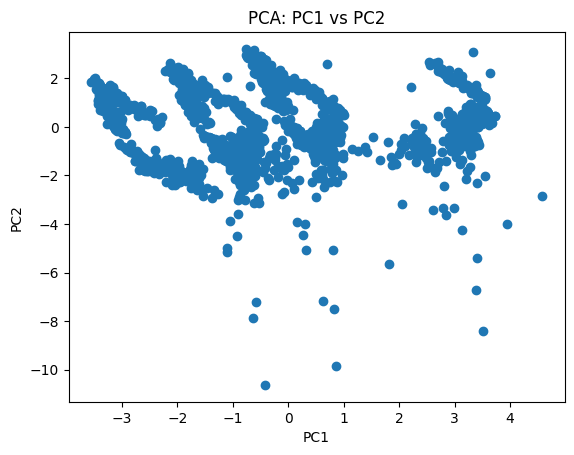

In [ ]:
#visualizar plot PCA PC1 X PC2
plt.scatter(df_pca["PC1"], df_pca["PC2"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: PC1 vs PC2") # Added a title for clarity
plt.show()